# Semana 1, clase 2: primer experimento reproducible

**Pregunta.** ¿Podemos clasificar vinos a partir de trece mediciones químicas mejor que una regla que siempre predice la clase más frecuente?

Hoy la regresión logística funciona como una herramienta de referencia. En la Semana 6 estudiaremos su formulación matemática. La meta de esta sesión es aprender a leer un experimento: filas, variables, partición, baseline, resultado y errores.

## 1. Preparación

Fijamos la semilla de la partición. Así podremos reconstruir exactamente las cifras de las diapositivas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 2105
plt.style.use("seaborn-v0_8-whitegrid")

## 2. ¿Qué representa una fila?

`load_wine` contiene 178 observaciones. Cada fila corresponde a un vino y cada columna a una medición química. La etiqueta toma tres valores, asociados con tres cultivares de la misma región de Italia.

Este conjunto es útil para aprender el procedimiento porque está limpio y viaja con `scikit-learn`. No representa por sí solo un problema operativo actual.

In [2]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y = wine.target.copy()

display(X.head(3))
print(f"X: {X.shape[0]} filas × {X.shape[1]} variables")
print(f"y: {y.shape[0]} etiquetas")
print("Clases:", dict(enumerate(wine.target_names)))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


X: 178 filas × 13 variables
y: 178 etiquetas
Clases: {0: 'class_0', 1: 'class_1', 2: 'class_2'}


,n,proporción
clase,,
0,59,0.331461
1,71,0.398876
2,48,0.269663


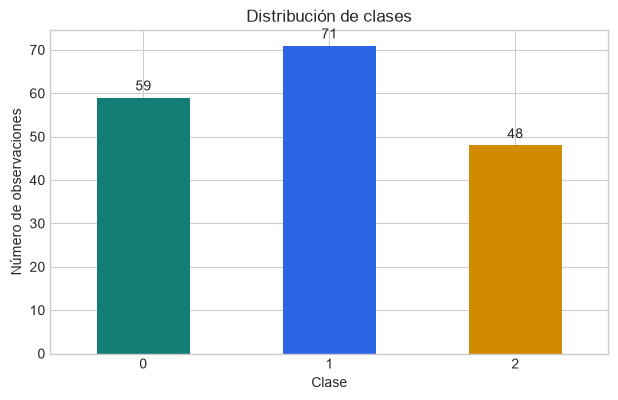

In [3]:
resumen_clases = (
    y.value_counts()
    .sort_index()
    .rename_axis("clase")
    .to_frame("n")
)
resumen_clases["proporción"] = resumen_clases["n"] / len(y)
display(resumen_clases)

ax = resumen_clases["n"].plot.bar(
    color=["#147d75", "#2b64e5", "#d28b00"],
    rot=0,
    legend=False,
    figsize=(7.2, 4.2),
)
ax.set(title="Distribución de clases", xlabel="Clase", ylabel="Número de observaciones")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

**Pausa.** Antes de ajustar un modelo, calcule una referencia:

1. ¿Cuál es la clase mayoritaria?
2. ¿Qué exactitud tendría una regla que siempre predice esa clase?
3. ¿Por qué esta cifra no requiere mirar ninguna variable de `X`?

In [4]:
clase_mayoritaria = int(y.mode().iloc[0])
accuracy_mayoritaria_total = float((y == clase_mayoritaria).mean())

print("Clase mayoritaria:", clase_mayoritaria)
print(f"Exactitud sobre el conjunto completo: {accuracy_mayoritaria_total:.3f}")

Clase mayoritaria: 1
Exactitud sobre el conjunto completo: 0.399


## 3. Separar antes de ajustar

Reservamos 25 % de los datos para una evaluación fuera del ajuste. `stratify=y` conserva aproximadamente la proporción de clases en ambas partes. El conjunto de prueba no se usará para elegir variables, hiperparámetros ni umbrales.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

proporciones = pd.concat(
    {
        "train": y_train.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    },
    axis=1,
)
print("Tamaños:", {"train": len(y_train), "test": len(y_test)})
display(proporciones.round(3))

Tamaños: {'train': 133, 'test': 45}


,train,test
target,,
0,0.331,0.333
1,0.398,0.400
2,0.271,0.267


## 4. Baseline

El baseline aprende cuál es la clase más frecuente **solo en entrenamiento** y la repite en test. Superarlo no garantiza que un modelo sea adecuado, pero no superarlo sí exige revisar el procedimiento.

In [6]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)
accuracy_baseline = accuracy_score(y_test, pred_baseline)

print(f"Exactitud del baseline en test: {accuracy_baseline:.3f}")

Exactitud del baseline en test: 0.400


## 5. Modelo de referencia

La tubería aprende el escalamiento con `X_train` y luego ajusta una regresión logística. Usar una tubería evita aplicar al test transformaciones aprendidas con información que no debía estar disponible.

In [7]:
modelo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)
modelo.fit(X_train, y_train)
pred_modelo = modelo.predict(X_test)
accuracy_modelo = accuracy_score(y_test, pred_modelo)

comparacion = pd.DataFrame(
    {
        "método": ["Clase mayoritaria", "Regresión logística"],
        "accuracy_test": [accuracy_baseline, accuracy_modelo],
    }
)
display(comparacion.style.format({"accuracy_test": "{:.3f}"}))
print(f"Diferencia absoluta: {accuracy_modelo - accuracy_baseline:.3f}")

,método,accuracy_test
0,Clase mayoritaria,0.400
1,Regresión logística,0.978


Diferencia absoluta: 0.578


## 6. ¿Dónde se equivoca?

Una exactitud resume aciertos, pero no muestra qué clases se confunden. En la matriz siguiente, las filas son clases observadas y las columnas son clases predichas.

,pred. 0,pred. 1,pred. 2
obs. 0,15,0,0
obs. 1,0,17,1
obs. 2,0,0,12


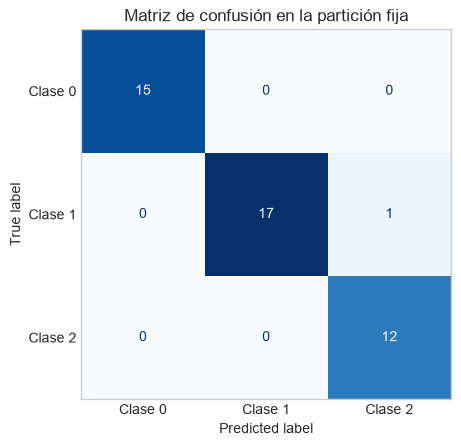

In [8]:
matriz = confusion_matrix(y_test, pred_modelo)
display(pd.DataFrame(matriz, index=["obs. 0", "obs. 1", "obs. 2"], columns=["pred. 0", "pred. 1", "pred. 2"]))

ConfusionMatrixDisplay(matriz, display_labels=["Clase 0", "Clase 1", "Clase 2"]).plot(
    cmap="Blues",
    colorbar=False,
)
plt.title("Matriz de confusión en la partición fija")
plt.grid(False)
plt.show()

In [9]:
reporte = pd.DataFrame(
    classification_report(
        y_test,
        pred_modelo,
        target_names=wine.target_names,
        output_dict=True,
    )
).T
display(reporte.round(3))

,precision,recall,f1-score,support
class_0,1.000,1.000,1.000,15.000
class_1,1.000,0.944,0.971,18.000
class_2,0.923,1.000,0.960,12.000
accuracy,0.978,0.978,0.978,0.978
macro avg,0.974,0.981,0.977,45.000
weighted avg,0.979,0.978,0.978,45.000


## 7. Conclusión que sí permiten estos resultados

En esta partición fija, el baseline acierta **18 de 45** observaciones (`accuracy = 0.400`) y la tubería de regresión logística acierta **44 de 45** (`accuracy = 0.978`). El único error confunde una observación de la clase 1 con la clase 2.

La conclusión es deliberadamente estrecha: el modelo supera la referencia en este conjunto limpio y en esta partición. Todavía no sabemos cómo se comportaría con mediciones de otro laboratorio, otra región o datos recolectados en otro momento. Tampoco estamos estimando una relación causal.

## 8. Comprobación final

Ejecute estas aserciones después de modificar el notebook. Si alguna falla, las cifras del cierre ya no coinciden con el experimento.

In [10]:
assert X.shape == (178, 13)
assert matriz.sum() == len(y_test) == 45
assert int(np.trace(matriz)) == 44
assert np.isclose(accuracy_baseline, 18 / 45)
assert np.isclose(accuracy_modelo, 44 / 45)
print("Comprobaciones superadas.")

Comprobaciones superadas.
